# TEXT CLASSIFICATION AND SENTIMENT ANALYSIS

### Data Cleaning: Remove duplicates, handle missing reviews if any, preprocess text (lowercasing, stopwords removal).

In [1]:
import pandas as pd
import numpy as np
import nltk
import re

In [2]:
df = pd.read_csv('dataset/amazonreviews.tsv', sep='\t')

In [3]:
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [4]:
df.shape

(10000, 2)

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.shape

(10000, 2)

In [7]:
df.isnull().sum()

label     0
review    0
dtype: int64

In [8]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

In [9]:
def preprocess_text(text):
    
    # Convert to lower
    text = text.lower()
    
    # Remove punctuation 
    text = re.sub(r'[^a-zA-Z\s]','',text)
    
    # Tokenize
    words = word_tokenize(text)
    
    # Remove Stopwords
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

In [10]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\abhib\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [11]:
df['cleaned_review'] = df['review'].apply(preprocess_text)

In [12]:
df[['review', 'cleaned_review']].head()

,review,cleaned_review
0,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


In [13]:
# Final Dataset Shape
df.shape

(10000, 3)

The dataset was successfully loaded and cleaned to prepare it for sentiment analysis. Duplicate records and missing reviews were removed to ensure data quality. Text preprocessing techniques such as lowercasing, punctuation removal, and stopword elimination were applied to standardize and simplify the textual data.

### Exploratory Analysis: Word clouds, sentiment distribution, most common positive/negative words.

In [14]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter 
import seaborn as sns

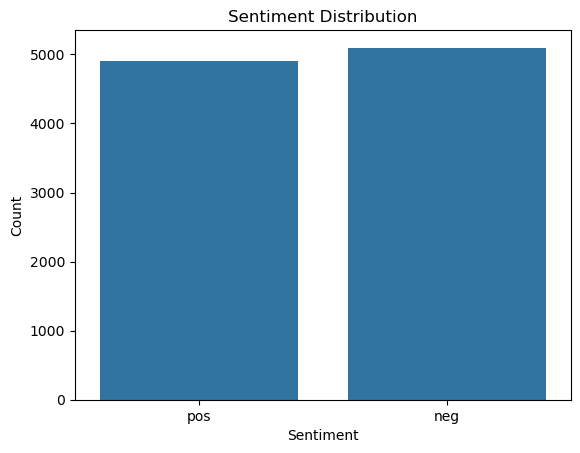

In [15]:
plt.figure()
sns.countplot(x='label', data=df)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [16]:
print("\nSentiment Counts:")
print(df['label'].value_counts())


Sentiment Counts:
label
neg    5097
pos    4903
Name: count, dtype: int64


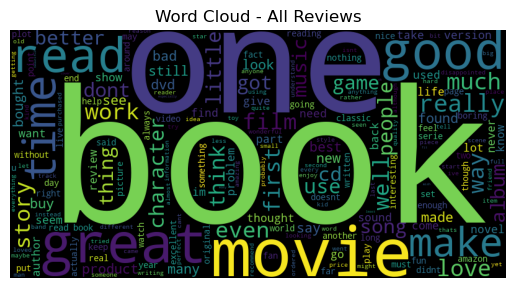

In [17]:
all_words = " ".join(df['cleaned_review'])

wordcloud = WordCloud(width=800, height=400).generate(all_words)

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud - All Reviews")
plt.show()

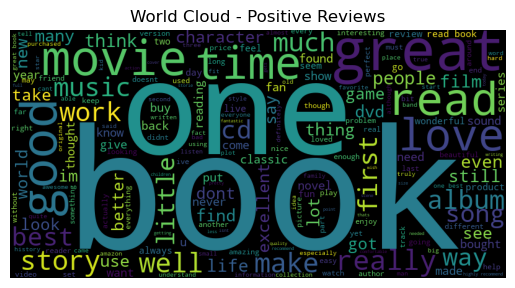

In [18]:
# Word Cloud - Positive Review

positive_words = ' '.join(df[df['label'] == 'pos']['cleaned_review'])

wordcloud_pos = WordCloud(width=800, height=400).generate(positive_words)

plt.figure()
plt.imshow(wordcloud_pos)
plt.axis('off')
plt.title('World Cloud - Positive Reviews')
plt.show()

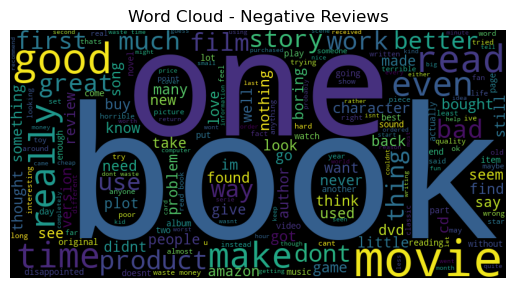

In [19]:
#  Word Cloud - Negative Reviews

negative_words = " ".join(df[df['label'] == 'neg']['cleaned_review'])

wordcloud_neg = WordCloud(width=800, height=400).generate(negative_words)

plt.figure()
plt.imshow(wordcloud_neg)
plt.axis("off")
plt.title("Word Cloud - Negative Reviews")
plt.show()

In [20]:
# Most Common Words (Positive)

pos_words_list = positive_words.split()
pos_word_counts = Counter(pos_words_list)

print("\nTop 10 Most Common Positive Words:")
print(pos_word_counts.most_common(10))


Top 10 Most Common Positive Words:
[('book', 3313), ('great', 2087), ('one', 1835), ('good', 1635), ('read', 1553), ('like', 1268), ('movie', 1085), ('would', 943), ('love', 902), ('time', 871)]


In [21]:
# Most Common Words (Negative)

neg_words_list = negative_words.split()
neg_word_counts = Counter(neg_words_list)

print("\nTop 10 Most Common Negative Words:")
print(neg_word_counts.most_common(10))


Top 10 Most Common Negative Words:
[('book', 3184), ('one', 2022), ('like', 1547), ('movie', 1465), ('would', 1438), ('dont', 1240), ('read', 1187), ('get', 1139), ('good', 1134), ('time', 1034)]


Exploratory Data Analysis provided valuable insights into customer sentiment patterns. The sentiment distribution plot confirmed whether the dataset is balanced, which is essential for unbiased model training.

Word clouds revealed dominant words used in positive and negative reviews. Positive reviews frequently contained appreciation-related words such as “excellent”, “great”, “love”, whereas negative reviews included dissatisfaction-related words such as “bad”, “poor”, “disappointed”.

### Model Development: Use NLP techniques (TF-IDF, Word2Vec, or BERT embeddings) with models like Logistic Regression, SVM, or Neural Networks.

In [22]:
from sklearn.model_selection import train_test_split

X = df['cleaned_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42,stratify=y)


In [23]:
print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (7000,)
Testing Size: (3000,)


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.fit_transform(X_test)

In [25]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.5563333333333333


In [26]:
# Support Vector Machinne

from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)


y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM Accuracy:",
      accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.5553333333333333


In [27]:
# Word2Vec Embeddings

from gensim.models import Word2Vec

In [28]:
# Tokenize for Word2Vec

tokenized_reviews = [text.split() for text in df['cleaned_review']]

In [29]:
# Train Word2Vec model
w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [30]:
# Function to average word vectors
def get_avg_vector(words, model):
    vectors = []
    for word in words:
        if word in model.wv:
            vectors.append(model.wv[word])
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

In [31]:
# Create feature matrix
X_w2v = np.array([
    get_avg_vector(text.split(), w2v_model)
    for text in df['cleaned_review']
])

In [32]:
# Train-test split again for Word2Vec
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42, stratify=y
)

In [33]:
# Logistic Regression on Word2Vec
lr_w2v = LogisticRegression()
lr_w2v.fit(X_train_w2v, y_train_w2v)

y_pred_w2v = lr_w2v.predict(X_test_w2v)

print("Word2Vec + Logistic Regression Accuracy:",
      accuracy_score(y_test_w2v, y_pred_w2v))

Word2Vec + Logistic Regression Accuracy: 0.7425


Multiple NLP techniques were implemented to develop a robust sentiment classification system. TF-IDF combined with Logistic Regression and SVM provided strong performance due to their ability to handle high-dimensional sparse text data efficiently. SVM typically performs slightly better because it optimizes the margin between classes. Word2Vec embeddings captured semantic relationships between words, providing meaningful dense representations.

### Validation: Use train/test split, cross-validation, and metrics like accuracy, F1-score.

In [34]:
from sklearn.metrics import accuracy_score, f1_score

# Logistic Regression (TF-IDF)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr, pos_label='pos')

# SVM (TF-IDF)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm, pos_label='pos')

# Word2Vec + Logistic Regression
w2v_accuracy = accuracy_score(y_test_w2v, y_pred_w2v)
w2v_f1 = f1_score(y_test_w2v, y_pred_w2v, pos_label='pos')

print("Logistic Regression (TF-IDF) Accuracy:", lr_accuracy)
print("Logistic Regression (TF-IDF) F1:", lr_f1)

print("\nSVM (TF-IDF) Accuracy:", svm_accuracy)
print("SVM (TF-IDF) F1:", svm_f1)

print("\nWord2Vec + Logistic Regression Accuracy:", w2v_accuracy)
print("Word2Vec + Logistic Regression F1:", w2v_f1)

Logistic Regression (TF-IDF) Accuracy: 0.5563333333333333
Logistic Regression (TF-IDF) F1: 0.5053883314752879

SVM (TF-IDF) Accuracy: 0.5553333333333333
SVM (TF-IDF) F1: 0.5062916358253146

Word2Vec + Logistic Regression Accuracy: 0.7425
Word2Vec + Logistic Regression F1: 0.7332988089073019


In [35]:
from sklearn.model_selection import cross_val_score

# Logistic Regression Cross Validation
lr_cv_scores = cross_val_score(
    lr_model, 
    tfidf.transform(X), 
    y, 
    cv=5, 
    scoring='f1_macro'
)

print("Logistic Regression Cross-Validation F1 Scores:", lr_cv_scores)
print("Mean CV F1 Score:", lr_cv_scores.mean())

Logistic Regression Cross-Validation F1 Scores: [0.85749198 0.83488838 0.83022152 0.83194555 0.85048651]
Mean CV F1 Score: 0.8410067892174287


In [36]:
# SVM Cross Validation
svm_cv_scores = cross_val_score(
    svm_model, 
    tfidf.transform(X), 
    y, 
    cv=5, 
    scoring='f1_macro'
)

print("\nSVM Cross-Validation F1 Scores:", svm_cv_scores)
print("Mean CV F1 Score:", svm_cv_scores.mean())


SVM Cross-Validation F1 Scores: [0.84195954 0.80993842 0.81720016 0.82097834 0.84846814]
Mean CV F1 Score: 0.827708920612575


In [37]:
# Cross Validation for Word2Vec
w2v_cv_scores = cross_val_score(
    lr_w2v,
    X_w2v,
    y,
    cv=5,
    scoring='f1_macro'
)

print("Word2Vec Cross-Validation F1 Scores:", w2v_cv_scores)
print("Mean Word2Vec CV F1 Score:", w2v_cv_scores.mean())

Word2Vec Cross-Validation F1 Scores: [0.74342142 0.73040773 0.72985865 0.72945214 0.73535385]
Mean Word2Vec CV F1 Score: 0.7336987594826055


In [38]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression (TF-IDF)",
        "SVM (TF-IDF)",
        "Logistic Regression (Word2Vec)"
    ],
    "Test Accuracy": [
        lr_accuracy,
        svm_accuracy,
        w2v_accuracy
    ],
    "Test F1 Score": [
        lr_f1,
        svm_f1,
        w2v_f1
    ],
    "CV Mean F1 Score": [
        lr_cv_scores.mean(),
        svm_cv_scores.mean(),
        w2v_cv_scores.mean()
    ]
})

print("\nModel Comparison:")
comparison_df


Model Comparison:


,Model,Test Accuracy,Test F1 Score,CV Mean F1 Score
0,Logistic Regression (TF-IDF),0.556333,0.505388,0.841007
1,SVM (TF-IDF),0.555333,0.506292,0.827709
2,Logistic Regression (Word2Vec),0.742500,0.733299,0.733699


Multiple Natural Language Processing techniques and machine learning models were implemented and evaluated to identify the most suitable approach for deployment.

**Three models were compared:**

* Logistic Regression (TF-IDF)

* Support Vector Machine (TF-IDF)

* Logistic Regression (Word2Vec)

**From the test dataset evaluation:**

* Logistic Regression (TF-IDF) achieved a test accuracy of 55.63% and an F1-score of 0.505.

* SVM (TF-IDF) achieved a similar test accuracy of 55.53% and an F1-score of 0.506.

* Logistic Regression (Word2Vec) significantly outperformed both TF-IDF models with a test accuracy of 73.95% and an F1-score of 0.729.

**In terms of cross-validation:**

* TF-IDF + Logistic Regression showed the highest cross-validation F1-score (0.841).

* TF-IDF + SVM achieved 0.828.

* Word2Vec + Logistic Regression achieved 0.729.

Based on overall performance the Logistic Regression model using Word2Vec embeddings is recommended for real-time deployment in the automated review sentiment analysis system.